# EDA on Sample of RAW Dataset 

In [17]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import sklearn as sk

In [18]:
# Cleaned dataset
df = pd.read_csv("Delayed_Cancelled_Flights.csv")

print("Full dataset size:", df.shape)

# Create 100k sample
df_sample = df.sample(n=100000, random_state=42)

# Save sample
df_sample.to_csv("Delayed_Cancelled_Flights_sample.csv", index=False)

print("Sample dataset saved.")
print("Sample size:", df_sample.shape)

Full dataset size: (1531038, 16)
Sample dataset saved.
Sample size: (100000, 16)


Sample dataset size: (100000, 16)

Delayed vs Cancelled Counts:
DELAYED
True     93514
False     6486
Name: count, dtype: int64

Average Delay Minutes by Cause:
LATE_AIRCRAFT_DELAY    28.376072
CARRIER_DELAY          25.306542
NAS_DELAY              13.324679
WEATHER_DELAY           3.966625
SECURITY_DELAY          0.127232
dtype: float64


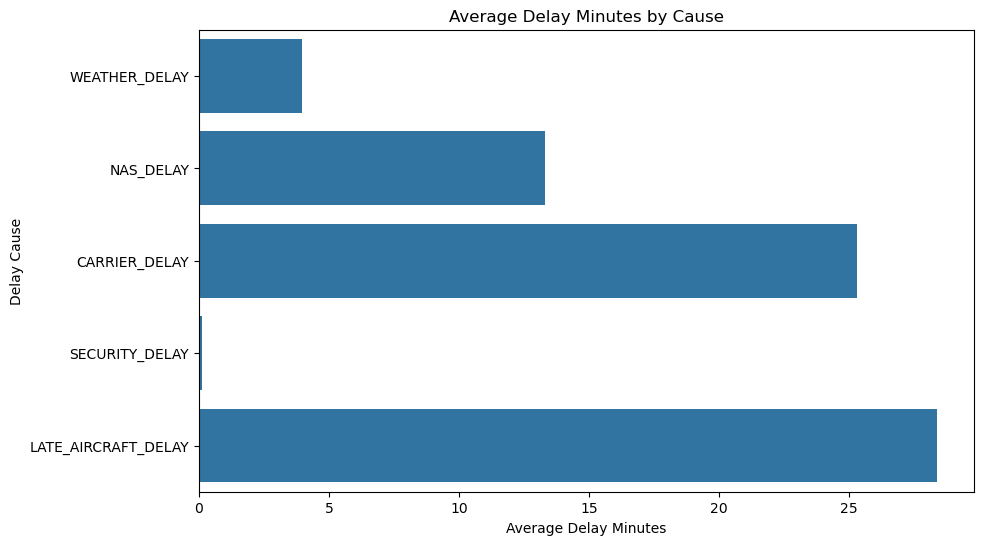

In [19]:
df = pd.read_csv("Delayed_Cancelled_Flights_sample.csv")

print("Sample dataset size:", df.shape)

# BASIC EDA
print("\nDelayed vs Cancelled Counts:")
print(df["DELAYED"].value_counts())

# Delay causes
delay_causes = [
    "WEATHER_DELAY",
    "NAS_DELAY",
    "CARRIER_DELAY",
    "SECURITY_DELAY",
    "LATE_AIRCRAFT_DELAY"
]

print("\nAverage Delay Minutes by Cause:")
print(df[delay_causes].mean().sort_values(ascending=False))

# Visualize delay causes
plt.figure(figsize=(10, 6))
sns.barplot(x=df[delay_causes].mean().values, y=delay_causes)
plt.title("Average Delay Minutes by Cause")
plt.xlabel("Average Delay Minutes")
plt.ylabel("Delay Cause")
plt.show()


Top 10 Departure Airports with Disruptions:
ORIGIN
DFW    5615
DEN    4730
ORD    4426
ATL    4426
CLT    3772
LAS    2752
MCO    2634
LAX    2503
PHX    2469
SEA    2328
dtype: int64


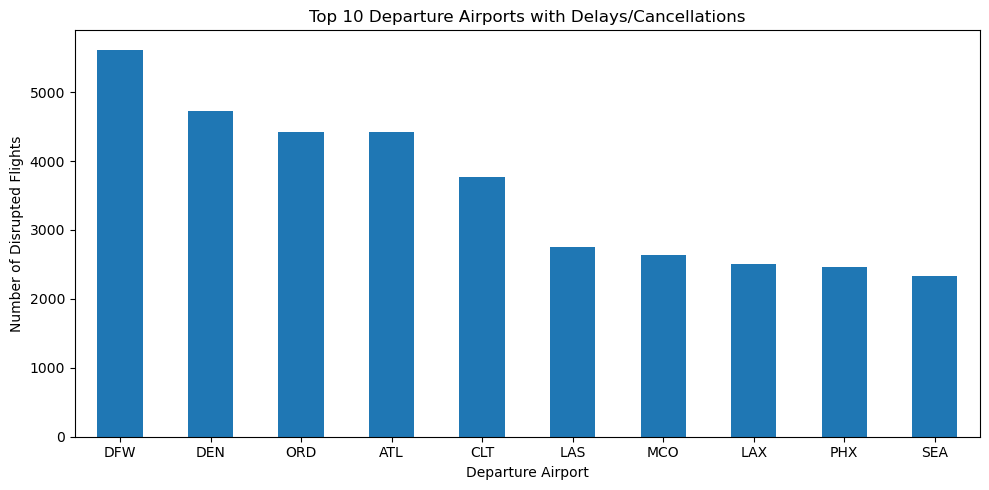

In [12]:
# TOP DEPARTURE AIRPORTS
top_airports = (
    df.groupby("ORIGIN")
      .size()
      .sort_values(ascending=False)
      .head(10)
)

print("\nTop 10 Departure Airports with Disruptions:")
print(top_airports)

top_airports.plot(kind="bar", figsize=(10,5))
plt.title("Top 10 Departure Airports with Delays/Cancellations")
plt.xlabel("Departure Airport")
plt.ylabel("Number of Disrupted Flights")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

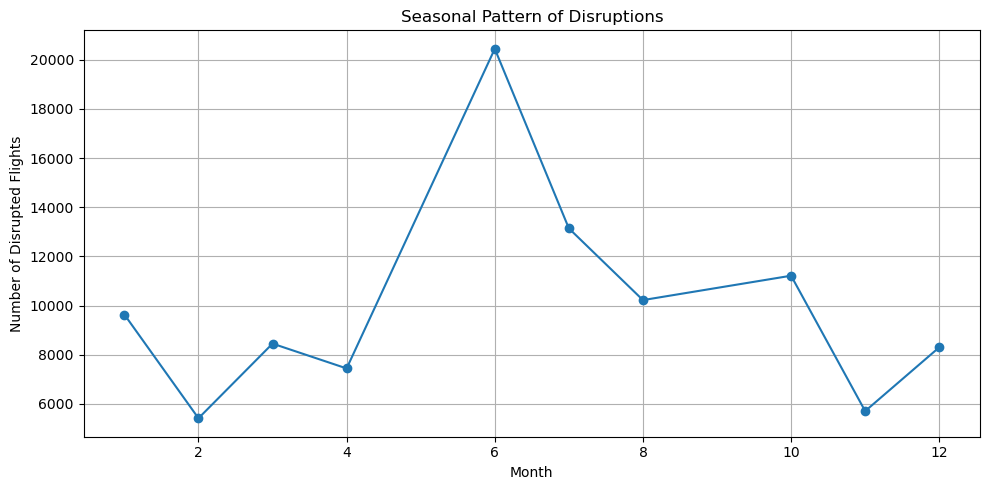

In [13]:
# SEASONAL ANALYSIS (MONTH)
monthly_disruptions = df.groupby("MONTH").size().sort_index()

monthly_disruptions.plot(marker="o", figsize=(10,5))
plt.title("Seasonal Pattern of Disruptions")
plt.xlabel("Month")
plt.ylabel("Number of Disrupted Flights")
plt.grid(True)
plt.tight_layout()
plt.show()

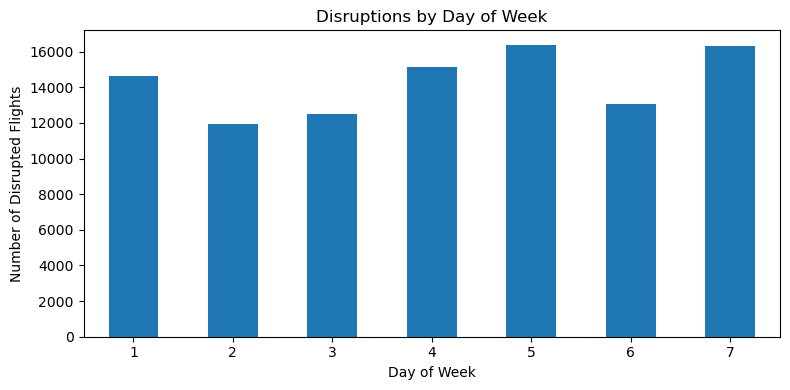

In [14]:
# DAY OF WEEK ANALYSIS
dow_disruptions = df.groupby("DAY_OF_WEEK").size().sort_index()

dow_disruptions.plot(kind="bar", figsize=(8,4))
plt.title("Disruptions by Day of Week")
plt.xlabel("Day of Week")
plt.ylabel("Number of Disrupted Flights")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

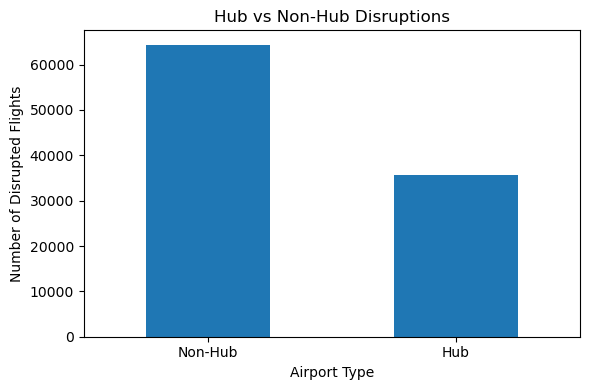

In [15]:
# HUB VS NON-HUB
hub_airports = top_airports.index.tolist()

df["HUB STATUS"] = df["ORIGIN"].apply(
    lambda x: "Hub" if x in hub_airports else "Non-Hub"
)

hub_counts = df["HUB STATUS"].value_counts()

hub_counts.plot(kind="bar", figsize=(6,4))
plt.title("Hub vs Non-Hub Disruptions")
plt.xlabel("Airport Type")
plt.ylabel("Number of Disrupted Flights")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


Average Delay Minutes by Hub Status:
            DEP_DELAY  ARR_DELAY
HUB STATUS                      
Hub         63.416753  66.376926
Non-Hub     69.853165  73.768278


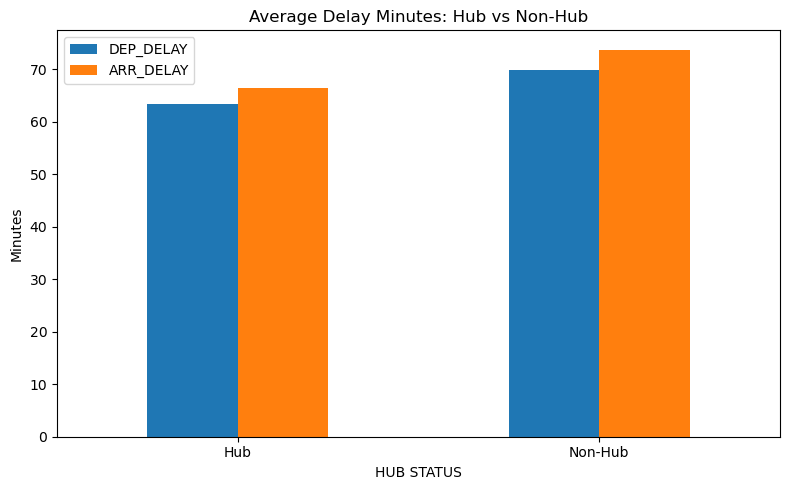

In [16]:
# HUB VS NON-HUB AVERAGE DELAYS
hub_delay_stats = (
    df.groupby("HUB STATUS")[["DEP_DELAY", "ARR_DELAY"]]
      .mean()
)

print("\nAverage Delay Minutes by Hub Status:")
print(hub_delay_stats)

hub_delay_stats.plot(kind="bar", figsize=(8,5))
plt.title("Average Delay Minutes: Hub vs Non-Hub")
plt.ylabel("Minutes")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [ ]:
# More Graphs